In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("/content/Housing.csv")
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [3]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


In [4]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [5]:
X = df[['area','bedrooms']]
y = df['price']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [8]:
print("Intercept :",model.intercept_)

print("Coefficients :")

for feature, coef in zip(X.columns, model.coef_):
    print(feature,":",coef)

Intercept : 642086.4086518651
Coefficients :
area : 389.22573013133035
bedrooms : 695678.6670515896


In [9]:
y_pred = model.predict(X_test)

In [10]:
comparison = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred})
print(comparison.head(10))

     Actual Price  Predicted Price
316       4060000     5.721233e+06
77        6650000     5.259090e+06
360       3710000     3.605916e+06
90        6440000     4.675251e+06
493       2800000     4.270456e+06
209       4900000     5.344719e+06
176       5250000     6.045326e+06
249       4543000     5.367037e+06
516       2450000     3.294535e+06
426       3353000     3.780032e+06


In [11]:
print("R2 Score :",r2_score(y_test, y_pred))
print("Mean Squared Error :",mean_squared_error(y_test, y_pred))

R2 Score : 0.3510473817558726
Mean Squared Error : 3280176595474.013


In [13]:
area = float(input("Enter the area of the house (Square Feet): "))
bedrooms = int(input("Enter the number of bedrooms: "))
price = model.predict([[area, bedrooms]])
print("\nPredicted Price = ${:.2f}".format(price[0]))

Enter the area of the house (Square Feet): 88
Enter the number of bedrooms: 4

Predicted Price = $3459052.94


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


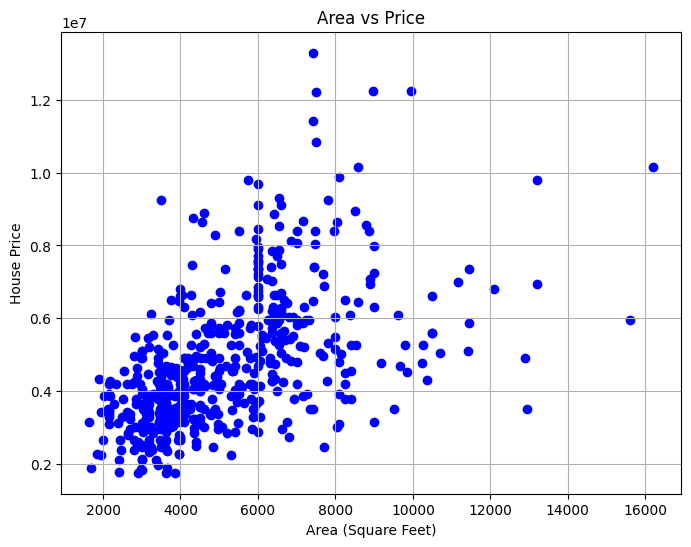

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(df['area'],df['price'],color='blue')

plt.xlabel('Area (Square Feet)')
plt.ylabel('House Price')
plt.title('Area vs Price')
plt.grid(True)
plt.show()